<a href="https://colab.research.google.com/github/AnasGamal/cs431-ml-models/blob/main/supervised/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

num_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test  = tf.keras.utils.to_categorical(y_test , num_classes)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [3]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=2)

Epoch 1/15
625/625 - 9s - 15ms/step - accuracy: 0.4540 - loss: 1.5102 - val_accuracy: 0.5620 - val_loss: 1.2344
Epoch 2/15
625/625 - 2s - 3ms/step - accuracy: 0.6068 - loss: 1.1172 - val_accuracy: 0.6487 - val_loss: 1.0147
Epoch 3/15
625/625 - 2s - 3ms/step - accuracy: 0.6657 - loss: 0.9563 - val_accuracy: 0.6589 - val_loss: 0.9816
Epoch 4/15
625/625 - 2s - 3ms/step - accuracy: 0.7036 - loss: 0.8459 - val_accuracy: 0.6782 - val_loss: 0.9348
Epoch 5/15
625/625 - 2s - 3ms/step - accuracy: 0.7357 - loss: 0.7561 - val_accuracy: 0.7094 - val_loss: 0.8412
Epoch 6/15
625/625 - 2s - 3ms/step - accuracy: 0.7625 - loss: 0.6776 - val_accuracy: 0.7277 - val_loss: 0.7866
Epoch 7/15
625/625 - 2s - 3ms/step - accuracy: 0.7863 - loss: 0.6158 - val_accuracy: 0.7284 - val_loss: 0.8108
Epoch 8/15
625/625 - 2s - 3ms/step - accuracy: 0.8073 - loss: 0.5546 - val_accuracy: 0.7347 - val_loss: 0.7909
Epoch 9/15
625/625 - 2s - 3ms/step - accuracy: 0.8283 - loss: 0.4920 - val_accuracy: 0.7113 - val_loss: 0.8771


In [5]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"Test accuracy = {test_acc:.3f}")

Test accuracy = 0.712


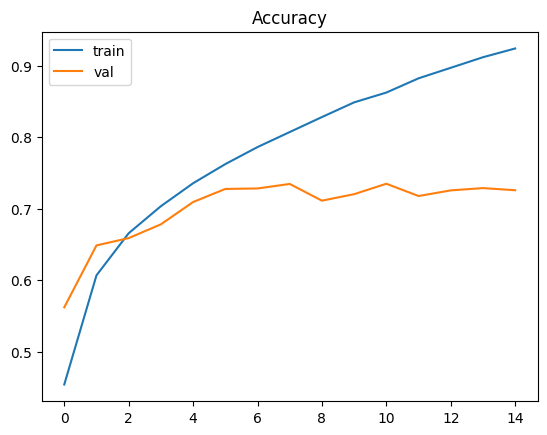

In [6]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title('Accuracy')
plt.show()